In [ ]:
#Import thư viện & Nạp dữ liệu ---
import sys
import pandas as pd

sys.path.append('..') 

from src.data.loader import fetch_and_load_data

# Tải dữ liệu gốc
df_raw = fetch_and_load_data()
print("Kích thước dữ liệu gốc:", df_raw.shape)
df_raw.head()

Dữ liệu đã tồn tại trong data/raw/.
Kích thước dữ liệu gốc: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


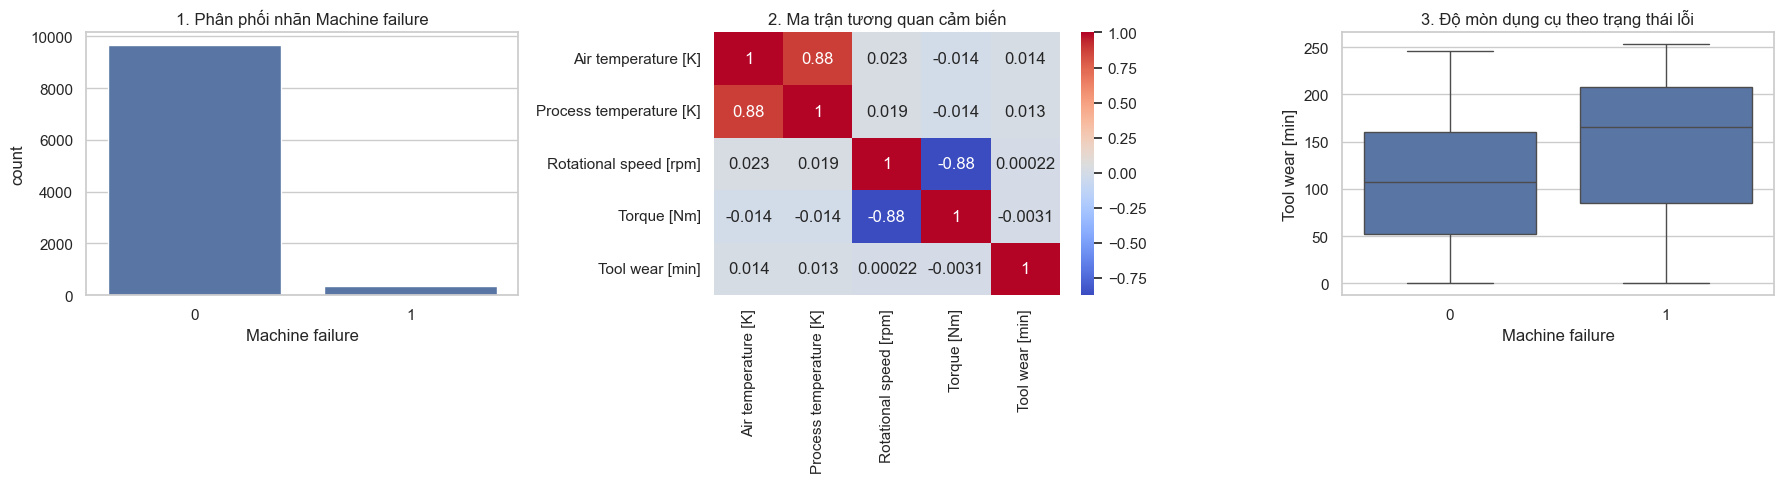

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập giao diện
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sơ đồ 1: Imbalance
sns.countplot(data=df_raw, x='Machine failure', ax=axes[0])
axes[0].set_title('1. Phân phối nhãn Machine failure')

# Sơ đồ 2: Correlation
sns.heatmap(df_raw[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].corr(), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('2. Ma trận tương quan cảm biến')

# Sơ đồ 3: Boxplot Tool wear
sns.boxplot(data=df_raw, x='Machine failure', y='Tool wear [min]', ax=axes[2])
axes[2].set_title('3. Độ mòn dụng cụ theo trạng thái lỗi')

plt.tight_layout()
plt.show()